# Lab 02 - EDA and Data Cleaning

## Data Story

We are helping a business understand how advertising spend relates to sales.

Business question:

**Which advertising channels appear most connected to sales?**

In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn

Defaulting to user installation because normal site-packages is not writeable
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.


  Using cached pandas-3.0.2-cp314-cp314-win_amd64.whl.metadata (19 kB)
  Using cached numpy-2.4.4-cp314-cp314-win_amd64.whl.metadata (6.6 kB)
  Using cached matplotlib-3.10.9-cp314-cp314-win_amd64.whl.metadata (52 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached tzdata-2026.2-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp314-cp314-win_amd64.whl.metadata (119 kB)
  Using cached kiwisolver-1.5.0-cp314-cp314-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.2.0-cp314-cp314-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached pandas-3.0.2-cp314-cp314-win_amd64.whl (9.9 MB)
Using cached numpy-2.4.4-c

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 50)

In [3]:
df = pd.read_csv("dataset/advertising.csv")
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


## 1. Understand the Data

First, check the size, columns, data types, and missing values.

In [3]:
print("Rows and columns:", df.shape)
display(df.info())
display(df.isnull().sum().to_frame("Missing Values"))
display(df.duplicated().sum())

NameError: name 'df' is not defined

## 2. Summary Statistics

This helps us understand typical spend and sales levels.

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
TV,200.0,147.0425,85.854236,0.7,74.375,149.75,218.825,296.4
Radio,200.0,23.2640,14.846809,0.0,9.975,22.90,36.525,49.6
Newspaper,200.0,30.5540,21.778621,0.3,12.750,25.75,45.100,114.0
Sales,200.0,15.1305,5.283892,1.6,11.000,16.00,19.050,27.0


## 3. Visual Story

Look at how each channel changes with sales.

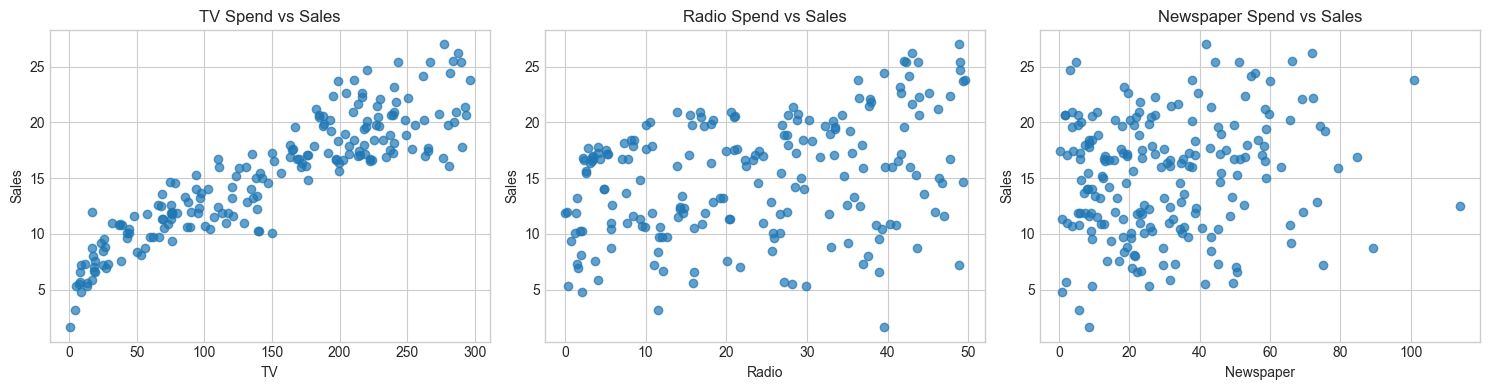

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["TV", "Radio", "Newspaper"]):
    ax.scatter(df[col], df["Sales"], alpha=0.7)
    ax.set_title(f"{col} Spend vs Sales")
    ax.set_xlabel(col)
    ax.set_ylabel("Sales")
plt.tight_layout()
plt.show()

## 4. Correlation Evidence

Correlation shows direction and strength of relationship.

,TV,Radio,Newspaper,Sales
TV,1.000000,0.054809,0.056648,0.901208
Radio,0.054809,1.000000,0.354104,0.349631
Newspaper,0.056648,0.354104,1.000000,0.157960
Sales,0.901208,0.349631,0.157960,1.000000


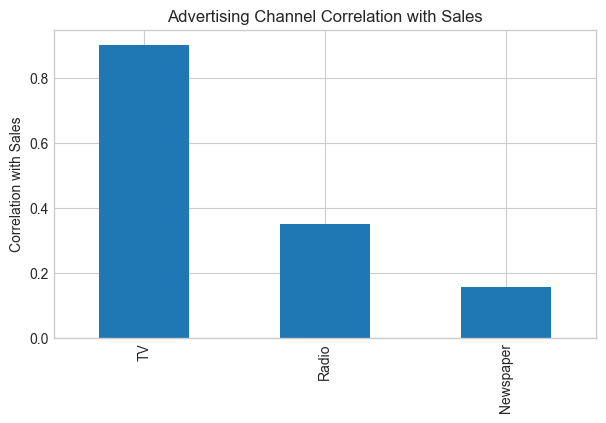

In [7]:
corr = df.corr(numeric_only=True)
display(corr)

corr["Sales"].drop("Sales").sort_values(ascending=False).plot(kind="bar", figsize=(7, 4))
plt.title("Advertising Channel Correlation with Sales")
plt.ylabel("Correlation with Sales")
plt.show()

## 5. Data Storytelling Conclusion

Write the conclusion in business language, not only technical language.

In [8]:
best_channel = corr["Sales"].drop("Sales").idxmax()
best_corr = corr.loc[best_channel, "Sales"]

print(f"Story conclusion: {best_channel} has the strongest relationship with Sales in this dataset.")
print(f"Correlation: {best_corr:.2f}")
print("Business action: prioritize deeper analysis of this channel before making budget decisions.")

Story conclusion: TV has the strongest relationship with Sales in this dataset.
Correlation: 0.90
Business action: prioritize deeper analysis of this channel before making budget decisions.


## Learner Reflection

Answer:

1. Which channel looks most useful?
2. Which channel looks weakest?
3. What extra data would make the story stronger?